In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
df = pd.read_csv('cleaned_data.csv')

print("✅ Cleaned data loaded!")
print(f"Shape       : {df.shape}")
print(f"Columns     : {df.columns.tolist()}")
print(f"Fake News   : {len(df[df['label']==0]):,}")
print(f"Real News   : {len(df[df['label']==1]):,}")
print(f"\nSample text:")
print(df['clean_text'][0][:200])

✅ Cleaned data loaded!
Shape       : (44223, 3)
Columns     : ['clean_text', 'label', 'word_count']
Fake News   : 22,807
Real News   : 21,416

Sample text:
ben stein call th circuit court committed coup dtat constitution st century wire say ben stein reputable professor pepperdine university also hollywood fame appearing tv show film ferris bueller day m


In [3]:
X = df['clean_text'].astype(str)
y = df['label']

print(f"✅ Features and labels prepared!")
print(f"Total samples : {len(X):,}")
print(f"Label 0 (Fake): {sum(y==0):,}")
print(f"Label 1 (Real): {sum(y==1):,}")

✅ Features and labels prepared!
Total samples : 44,223
Label 0 (Fake): 22,807
Label 1 (Real): 21,416


In [4]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_tfidf = tfidf.fit_transform(X)

print("✅ TF-IDF Vectorization complete!")
print(f"Matrix shape     : {X_tfidf.shape}")
print(f"  → {X_tfidf.shape[0]:,} articles")
print(f"  → {X_tfidf.shape[1]:,} features")
print(f"\nVocabulary size  : {len(tfidf.vocabulary_):,}")
print(f"Matrix sparsity  : {100*(1 - X_tfidf.nnz/(X_tfidf.shape[0]*X_tfidf.shape[1])):.2f}%")

✅ TF-IDF Vectorization complete!
Matrix shape     : (44223, 10000)
  → 44,223 articles
  → 10,000 features

Vocabulary size  : 10,000
Matrix sparsity  : 98.40%


In [5]:
feature_names = tfidf.get_feature_names_out()

fake_indices = df[df['label'] == 0].index
real_indices = df[df['label'] == 1].index

fake_tfidf_mean = np.array(
    X_tfidf[fake_indices].mean(axis=0)).flatten()
real_tfidf_mean = np.array(
    X_tfidf[real_indices].mean(axis=0)).flatten()

top_fake_idx = fake_tfidf_mean.argsort()[-15:][::-1]
top_real_idx = real_tfidf_mean.argsort()[-15:][::-1]

print("🔴 Top 15 TF-IDF Features — FAKE News:")
for i, idx in enumerate(top_fake_idx):
    print(f"  {i+1:2}. {feature_names[idx]:<25} "
          f"score: {fake_tfidf_mean[idx]:.4f}")

print("\n🟢 Top 15 TF-IDF Features — REAL News:")
for i, idx in enumerate(top_real_idx):
    print(f"  {i+1:2}. {feature_names[idx]:<25} "
          f"score: {real_tfidf_mean[idx]:.4f}")

🔴 Top 15 TF-IDF Features — FAKE News:
   1. trump                     score: 0.0370
   2. video                     score: 0.0262
   3. people                    score: 0.0207
   4. one                       score: 0.0200
   5. image                     score: 0.0198
   6. like                      score: 0.0197
   7. hillary                   score: 0.0192
   8. obama                     score: 0.0184
   9. president                 score: 0.0182
  10. clinton                   score: 0.0181
  11. via                       score: 0.0170
  12. time                      score: 0.0170
  13. american                  score: 0.0169
  14. said                      score: 0.0168
  15. donald                    score: 0.0168

🟢 Top 15 TF-IDF Features — REAL News:
   1. said                      score: 0.0423
   2. reuters                   score: 0.0328
   3. trump                     score: 0.0264
   4. state                     score: 0.0248
   5. president                 score: 0.0226
   

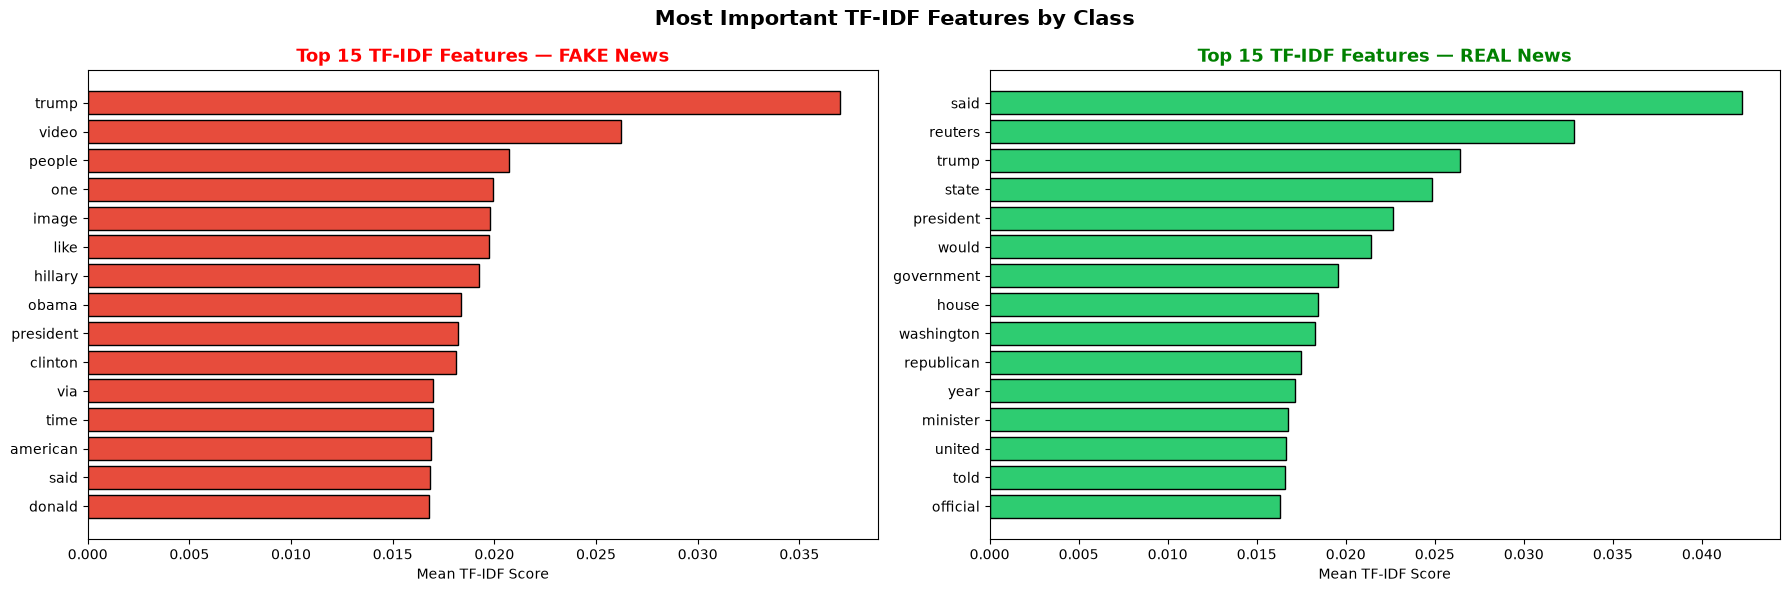

✅ TF-IDF features chart saved!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

fake_words  = [feature_names[i] for i in top_fake_idx]
fake_scores = [fake_tfidf_mean[i] for i in top_fake_idx]

axes[0].barh(fake_words[::-1], fake_scores[::-1],
             color='#e74c3c', edgecolor='black')
axes[0].set_title('Top 15 TF-IDF Features — FAKE News',
    fontsize=13, fontweight='bold', color='red')
axes[0].set_xlabel('Mean TF-IDF Score')

real_words  = [feature_names[i] for i in top_real_idx]
real_scores = [real_tfidf_mean[i] for i in top_real_idx]

axes[1].barh(real_words[::-1], real_scores[::-1],
             color='#2ecc71', edgecolor='black')
axes[1].set_title('Top 15 TF-IDF Features — REAL News',
    fontsize=13, fontweight='bold', color='green')
axes[1].set_xlabel('Mean TF-IDF Score')

plt.suptitle('Most Important TF-IDF Features by Class',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('tfidf_top_features.png', dpi=150)
plt.show()

print("✅ TF-IDF features chart saved!")

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("✅ Train/Test Split complete!")
print(f"\nTraining set  : {X_train.shape[0]:,} samples")
print(f"Testing set   : {X_test.shape[0]:,} samples")
print(f"\nTraining labels:")
print(f"  Fake (0): {sum(y_train==0):,}")
print(f"  Real (1): {sum(y_train==1):,}")
print(f"\nTesting labels:")
print(f"  Fake (0): {sum(y_test==0):,}")
print(f"  Real (1): {sum(y_test==1):,}")

✅ Train/Test Split complete!

Training set  : 35,378 samples
Testing set   : 8,845 samples

Training labels:
  Fake (0): 18,245
  Real (1): 17,133

Testing labels:
  Fake (0): 4,562
  Real (1): 4,283


In [8]:
import scipy.sparse as sp

os.makedirs('saved_models', exist_ok=True)

# Save TF-IDF vectorizer
pickle.dump(tfidf,
    open('saved_models/tfidf_vectorizer.pkl', 'wb'))

# Save train/test splits
sp.save_npz('saved_models/X_train.npz', X_train)
sp.save_npz('saved_models/X_test.npz',  X_test)
np.save('saved_models/y_train.npy', y_train)
np.save('saved_models/y_test.npy',  y_test)

print("✅ All files saved!")
print("\n📁 Files in saved_models/:")
print("   - tfidf_vectorizer.pkl")
print("   - X_train.npz")
print("   - X_test.npz")
print("   - y_train.npy")
print("   - y_test.npy")

✅ All files saved!

📁 Files in saved_models/:
   - tfidf_vectorizer.pkl
   - X_train.npz
   - X_test.npz
   - y_train.npy
   - y_test.npy


In [9]:
print("=" * 55)
print("  FEATURE ENGINEERING SUMMARY — Hansaja (Member 1)")
print("=" * 55)
print(f"""
🔧 METHOD
   Technique     : TF-IDF
   Max Features  : 10,000
   N-gram Range  : (1,2) unigrams + bigrams
   Min Doc Freq  : 2
   Max Doc Freq  : 95%
   Sublinear TF  : True

📊 RESULTS
   Input Samples : {len(X):,}
   Feature Matrix: {X_tfidf.shape[0]:,} × {X_tfidf.shape[1]:,}
   Training Set  : {X_train.shape[0]:,} samples
   Testing Set   : {X_test.shape[0]:,} samples

💡 WHY TF-IDF?
   Gives higher weight to important words that are
   rare across documents — ideal for distinguishing
   fake vs real news writing styles.

📁 SAVED
   ✅ tfidf_vectorizer.pkl
   ✅ X_train.npz / X_test.npz
   ✅ y_train.npy / y_test.npy
   ✅ tfidf_top_features.png
""")

  FEATURE ENGINEERING SUMMARY — Hansaja (Member 1)

🔧 METHOD
   Technique     : TF-IDF
   Max Features  : 10,000
   N-gram Range  : (1,2) unigrams + bigrams
   Min Doc Freq  : 2
   Max Doc Freq  : 95%
   Sublinear TF  : True

📊 RESULTS
   Input Samples : 44,223
   Feature Matrix: 44,223 × 10,000
   Training Set  : 35,378 samples
   Testing Set   : 8,845 samples

💡 WHY TF-IDF?
   Gives higher weight to important words that are
   rare across documents — ideal for distinguishing
   fake vs real news writing styles.

📁 SAVED
   ✅ tfidf_vectorizer.pkl
   ✅ X_train.npz / X_test.npz
   ✅ y_train.npy / y_test.npy
   ✅ tfidf_top_features.png

